# 📊 Rapport d'Expertise MLOps : Système de Scoring de Crédit
## 📝 Présentation du Pipeline

Ce notebook constitue la phase d'Exploration et de Validation (EDA) de notre projet MLOps. L'objectif ici est de transformer des données brutes en signaux prédictifs fiables pour notre modèle final. Cette démarche garantit que le code déployé dans notre conteneur Docker repose sur des réalités statistiques solides.

## 🎯 Objectifs Stratégiques

    - Compréhension du Risque : Identifier les variables clés (FICO, DTI) qui expliquent la hausse des taux de défaut.

    - Feature Engineering : Créer et valider des variables synthétiques (Ratio Dette/Revenu) qui seront ensuite intégrées en temps réel dans notre API FastAPI.

    - Préparation à l'Industrialisation : Définir les étapes de nettoyage (Imputation, Scaling) qui seront automatisées dans le script data_manager.py.

## Table des Matières

    Configuration et Chargement

    Audit de Qualité des Données

    Analyse de la Variable Cible

    Analyse des Facteurs de Risque (FICO & Revenus)

    Étude des Corrélations et Colinéarité

    Impact de la Stabilité Professionnelle

    Feature Engineering : Le Ratio DTI

    Analyse du Surendettement

    Synthèse Multidimensionnelle

## Importation des bibliothèques et configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

Le dataset contient 10000 lignes et 8 colonnes.


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


## Chargement du Dataset

In [ ]:
# Chargement des données
df = pd.read_csv('data/bank-risk-manage_dataset.csv')

# Aperçu
print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")
df.head()

## Audit de Qualité des Données

In [3]:
# Vérification des types et des valeurs manquantes
info_df = pd.DataFrame({
    'Type': df.dtypes,
    'Valeurs Manquantes': df.isnull().sum(),
    '% Manquant': (df.isnull().sum() / len(df)) * 100
})
print(info_df)



                             Type  Valeurs Manquantes  % Manquant
customer_id                 int64                   0         0.0
credit_lines_outstanding    int64                   0         0.0
loan_amt_outstanding      float64                   0         0.0
total_debt_outstanding    float64                   0         0.0
income                    float64                   0         0.0
years_employed              int64                   0         0.0
fico_score                  int64                   0         0.0
default                     int64                   0         0.0


## Analyse de la Variable Cible -- Distribution du risque de défaut

Nombre de cas :
default
0    8149
1    1851
Name: count, dtype: int64


C:\Users\utilisateurm\AppData\Local\Temp\ipykernel_25376\443233173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='default', data=df, palette='magma')


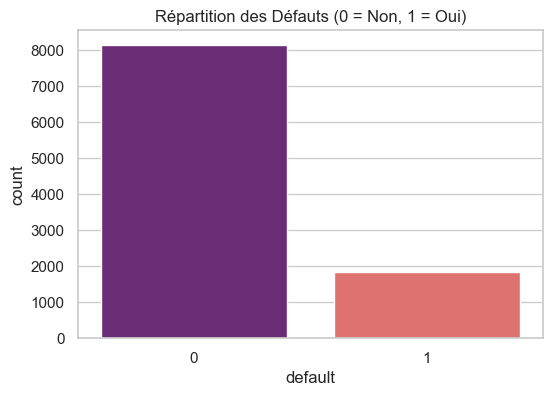

In [4]:
# Distribution de la variable cible
print("Nombre de cas :")
print(df['default'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='default', data=df, palette='magma')
plt.title('Répartition des Défauts (0 = Non, 1 = Oui)')
plt.show()

## Analyse du Déséquilibre des Classes

Le dataset présente un taux de défaut de 18,51 % (1 851 cas) contre 81,49 % de clients sains. Bien que les données soient déséquilibrées, la minorité (cas de défaut) est suffisamment représentée pour permettre un apprentissage.


## Analyse des Facteurs de Risque

### Analyse du Score FICO

C:\Users\utilisateurm\AppData\Local\Temp\ipykernel_25376\2191383108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='fico_score', data=df, palette='viridis')


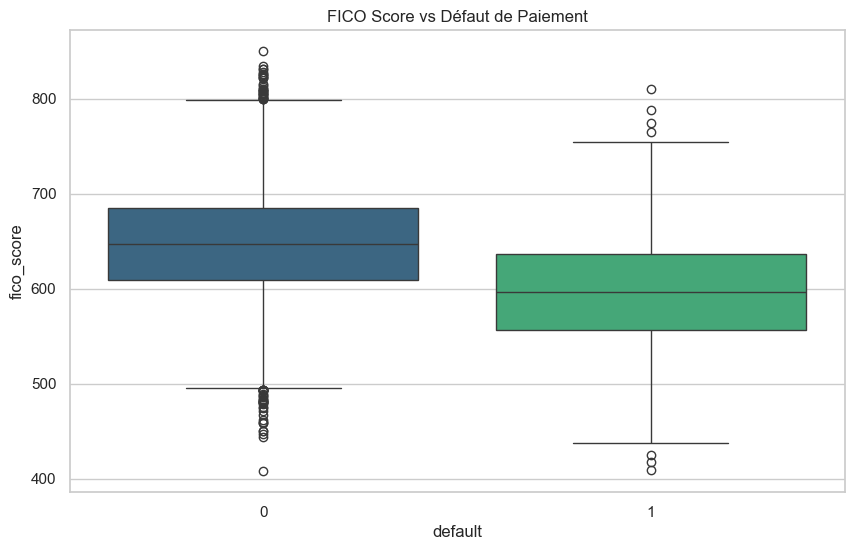

In [11]:
# Comparaison du FICO Score selon le statut de défaut
plt.figure(figsize=(10, 6))
sns.boxplot(x='default', y='fico_score', data=df, palette='viridis')
plt.title('FICO Score vs Défaut de Paiement')
plt.show()



Les clients en défaut ont un score FICO médian nettement plus bas (≈600) que les clients sains (≈650). Le score FICO semble etre un bon prédicteur mais imparfait, car il existe de nombreux "outliers" : certains clients avec un score de 800 font défaut, tandis que d'autres à 450 ne font pas défaut. 

### Relation Revenu vs Dette

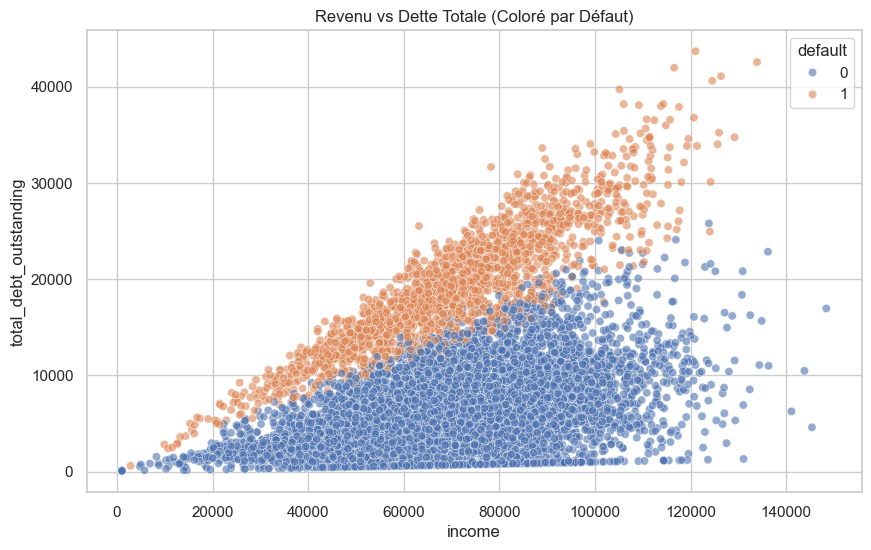

In [12]:
# Relation entre Revenu et Dette Totale
plt.figure(figsize=(10, 6))
sns.scatterplot(x='income', y='total_debt_outstanding', hue='default', data=df, alpha=0.6)
plt.title('Revenu vs Dette Totale (Coloré par Défaut)')
plt.show()

On observe une séparation diagonale très nette. Les défauts (orange) se concentrent systématiquement sur la partie supérieure du nuage de points. Le risque ne dépend pas du revenu seul, mais de la capacité de remboursement (le poids de la dette face au revenu). Cela justifie la création d'une nouvelle variable synthétique : le DTI_Ratio = Income /Total_Debt​.

## Étude des Corrélations

### Matrice de corrélation

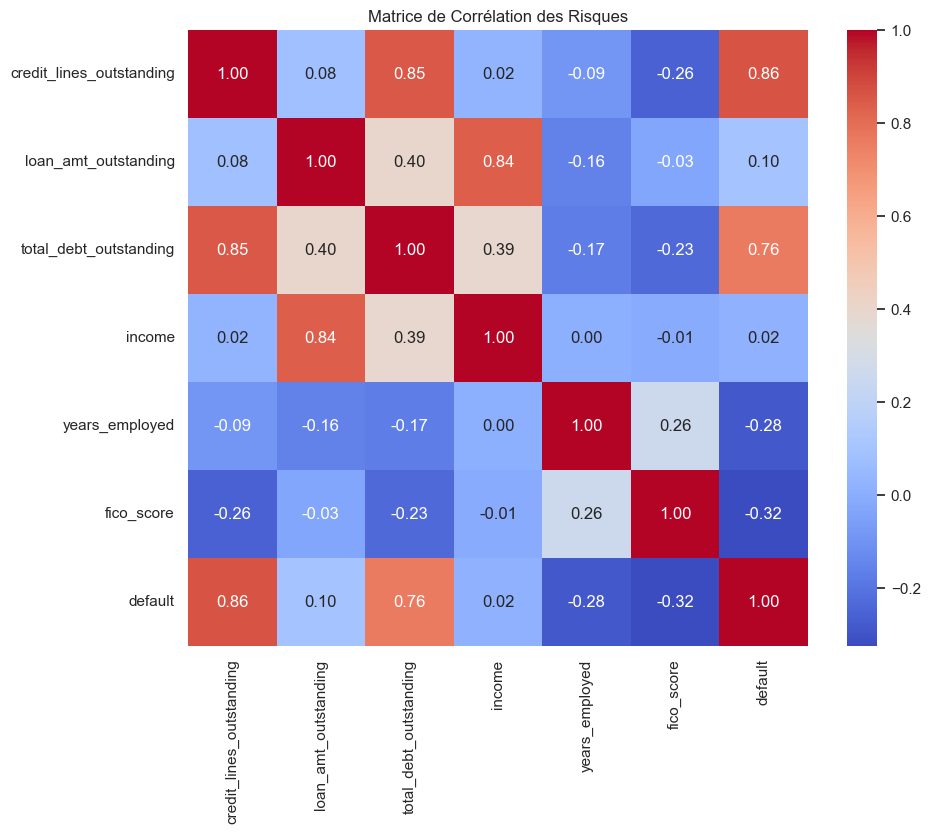

In [6]:
# On retire customer_id qui est juste un identifiant et ne sert pas à la prédiction
df_numeric = df.drop(columns=['customer_id'])

plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des Risques')
plt.show()

Le nombre de lignes de crédit (0.86) et la dette totale (0.76) sont les variables les plus corrélées au défaut. On note une très forte corrélation entre credit_lines_outstanding et total_debt_outstanding (0.85), qui apportent une information redondante pour des modèles linéaires (Régression Logistique).

## Impact de la Stabilité Professionnelle

### Distribution des années d'emploi

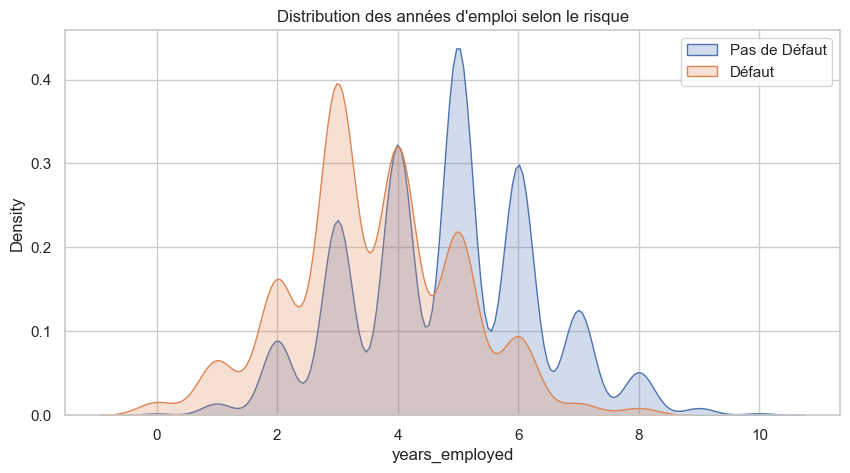

In [7]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['default'] == 0], x='years_employed', label='Pas de Défaut', fill=True)
sns.kdeplot(data=df[df['default'] == 1], x='years_employed', label='Défaut', fill=True)
plt.legend()
plt.title('Distribution des années d\'emploi selon le risque')
plt.show()

Le risque de défaut est maximal pour les clients ayant entre 2 et 4 ans d'ancienneté. Au-delà de 6 ans d'ancienneté, la densité des défauts s'effondre. La stabilité dans l'emploi semble agir comme un "bouclier" contre le risque financier. 

## Feature Engineering

### Analyse discriminante du Ratio DTI

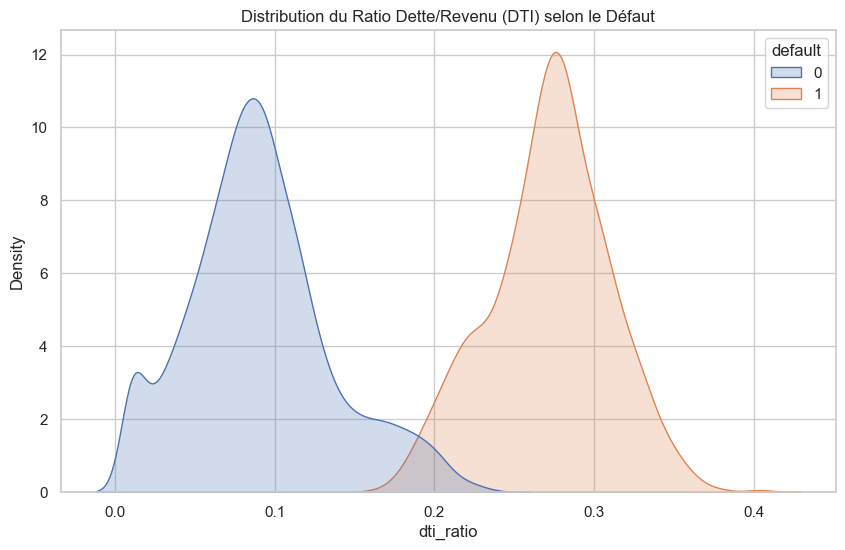

In [ ]:
# Feature Engineering Exploratoire
df['dti_ratio'] = df['total_debt_outstanding'] / df['income']

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='dti_ratio', hue='default', fill=True, common_norm=False)
plt.title('Distribution du Ratio Dette/Revenu (DTI) selon le Défaut')
plt.show()

La séparation est bimodale et quasi parfaite. Le groupe "Sain" culmine à un ratio de 0.1, tandis que le groupe "Défaut" explose à 0.28. Le point de bascule se situe autour de 0.18 - 0.20. C'est une variable assez discriminante.

## Analyse du Surendettement

### Impact du nombre de lignes de crédit

C:\Users\utilisateurm\AppData\Local\Temp\ipykernel_25376\1274123771.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='credit_lines_outstanding', y='default', data=df, palette='viridis')


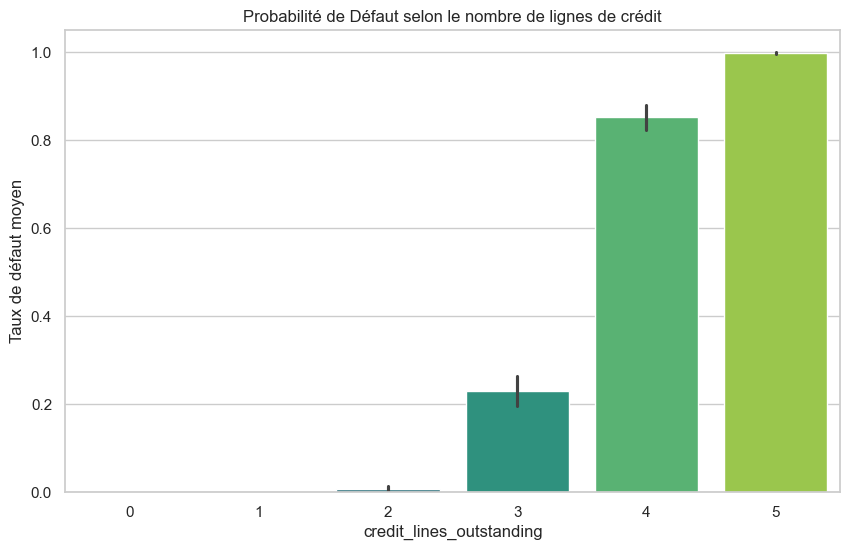

In [ ]:
# Analyse des lignes de crédit
plt.figure(figsize=(10, 6))
sns.barplot(x='credit_lines_outstanding', y='default', data=df, palette='viridis')
plt.title('Probabilité de Défaut selon le nombre de lignes de crédit')
plt.ylabel('Taux de défaut moyen')
plt.show()

Le taux de défaut reste proche de 0% jusqu'à 2 lignes de crédit. Il monte à 20% pour 3 lignes et dépasse les 80% dès la 4ème ligne. Il existe un "effet de falaise". Un client possédant 4 lignes de crédit ou plus est statistiquement en situation de surendettement critique.

## Analyse Bivariée

### FICO Score vs DTI Ratio

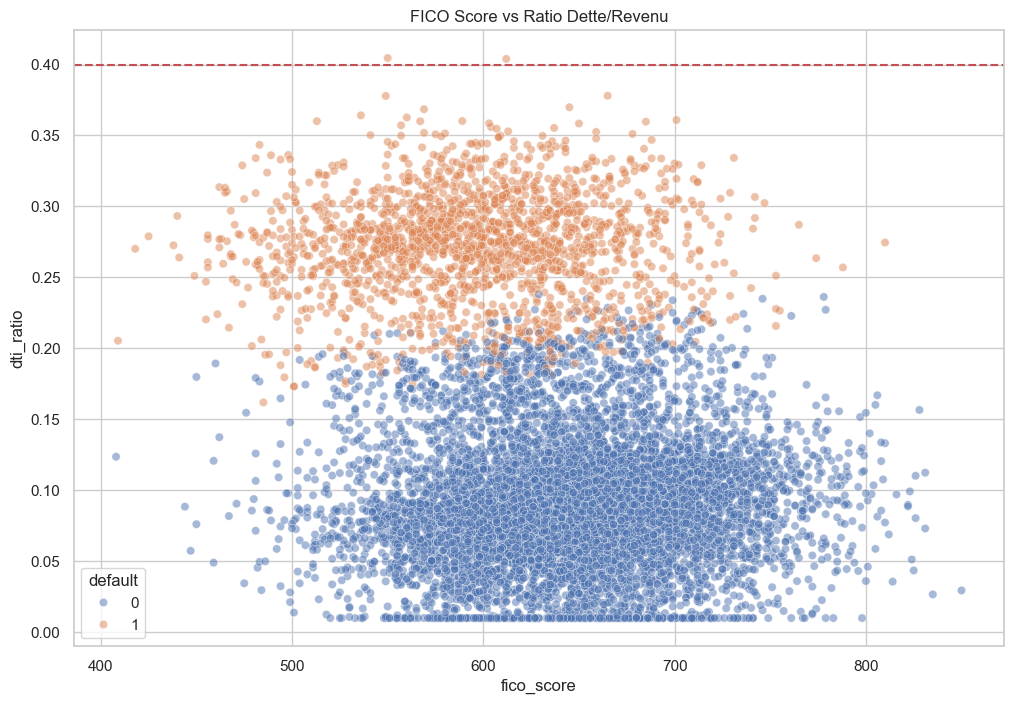

In [ ]:
# Analyse Bivariée FICO Score vs DTI Ratio
plt.figure(figsize=(12, 8))
sns.scatterplot(x='fico_score', y='dti_ratio', hue='default', data=df, alpha=0.5)
plt.axhline(y=0.4, color='r', linestyle='--') # Seuil hypothétique
plt.title('FICO Score vs Ratio Dette/Revenu')
plt.show()

La majorité des défauts sont piégés au-dessus d'un ratio DTI de 0.20, quel que soit le score FICO. Nous disposons de signaux très clairs. La modélisation devrait obtenir d'excellents scores de précision. 